<a href="https://colab.research.google.com/github/ben854719/Patient-Electronic-Health-Record-System/blob/main/Pytorch_Patient_Record.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
from IPython import get_ipython
from IPython import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim

# Import the dataset for the risk management of the new drugs by Health Canada.
risk_management_new_drug_health_canada_df = pd.read_csv('risk_management_new drug_health canada.csv')

# Create Scaler Object.
scaler =  StandardScaler()

# Numpy array for the dataset.
numerical_features = ['Lead_Office_Fro', 'Product_Line', 'DSTS_No', 'SAP_No', 'Product_Name', 'Active_Ingred', 'Review_Type', 'Date_Received', 'Date_Assigned', 'Date_Finish', 'Gender', 'Age', 'Provinces', 'Fiscal_Year']

for feature in numerical_features:
  if risk_management_new_drug_health_canada_df[feature].dtype == object:
    le = LabelEncoder()
    risk_management_new_drug_health_canada_df[feature] = le.fit_transform(risk_management_new_drug_health_canada_df[feature])

# fit the scaler to the numerical features.
scaler.fit(risk_management_new_drug_health_canada_df[numerical_features])

# Transform the data.
risk_management_new_drug_health_canada_df[numerical_features] = scaler.transform(risk_management_new_drug_health_canada_df[numerical_features])

# Create the tensor of input features and target variable.
X = torch.tensor(risk_management_new_drug_health_canada_df[['Lead_Office_Fro', 'Product_Line', 'DSTS_No', 'SAP_No', 'Product_Name', 'Active_Ingred', 'Review_Type', 'Date_Received', 'Date_Assigned', 'Date_Finish', 'Gender', 'Age', 'Provinces', 'Fiscal_Year']].values, dtype=torch.float32)
Y = torch.tensor(risk_management_new_drug_health_canada_df['Fiscal_Year'].values, dtype=torch.float32) # Changed 'value' to 'Fiscal_Year'

# train the model of the dataset.
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# set a random seed.
torch.manual_seed(42)

# Scale target variable
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert y_train and y_test back to PyTorch tensors and reshape
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Check for NaN/Inf in input and target
x_train[torch.isnan(x_train)] = 0
x_train[torch.isinf(x_train)] = 0
y_train[torch.isnan(y_train)] = 0
y_train[torch.isinf(y_train)] = 0
x_test[torch.isnan(x_test)] = 0
x_test[torch.isinf(x_test)] = 0
y_test[torch.isnan(y_test)] = 0
y_test[torch.isinf(y_test)] = 0

# Define the model using nn.Sequential.
model = nn.Sequential(
    nn.Linear(14, 32), # Input layer expects 14 features
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

# MSE Loss Function + optimizer.
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 200

epoch_format = 'Epoch[{0}' + str(num_epochs)+'], MSE.loss:{1}'

for epoch in range(num_epochs):
    predictions = model(x_train)
    MSE = loss_fn(predictions, y_train)

    # Check if loss is NaN and break.
    if torch.isnan(MSE):
        print(f"Loss is NaN at epoch {epoch + 1}. Stopping training.")
        break

    MSE.backward()

# Check for NaN/Inf in model parameters and break.
    for name, param in model.named_parameters():
        if torch.isnan(param.grad).any() or torch.isinf(param.grad).any():
            display.display(f"NaN or Inf detected in gradients for parameter '{name}' at epoch {epoch + 1}.")
            break

    # Replace NaN/Inf in gradients with 0
    for name, param in model.named_parameters():
        if torch.isnan(param.grad).any() or torch.isinf(param.grad).any():
            param.grad.data.fill_(0)

# Gradient Clipping.
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

for m in model.modules():
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

optimizer.step()
optimizer.zero_grad()

if (epoch+1) % 100 == 0:
  display.display(epoch_format.format(epoch + 1, MSE.item()))

'Epoch[200200], MSE.loss:0.009341221302747726'

In [32]:
# formula for torch save.
torch.save(model.state_dict(), 'model.pth')

In [33]:
# Load the model.
model = nn.Sequential(
    nn.Linear(14, 32),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

for m in model.modules():
   if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

# Load the state dictionary directly into the model
model.load_state_dict(torch.load('model.pth', weights_only=True))

# Set the model to evaluation mode.
model.eval()

#Replace NaN Valies in x_test with 0.
x_test[torch.isnan(x_test)] = 0

# Make predictions and calculate MSE.
with torch.no_grad():
    predictions = model(x_test)
    MSE = loss_fn(predictions, y_test)
    display.display(MSE)

tensor(0.3521)

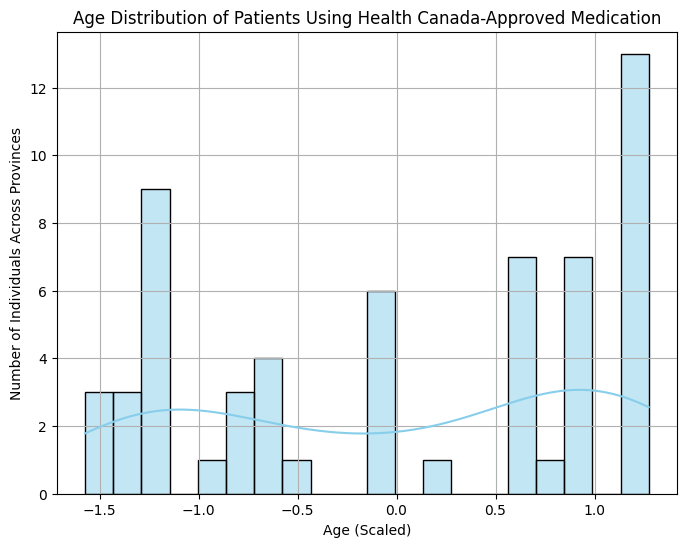

In [34]:
# Data Visualization for the dataset.

plt.figure(figsize=(8, 6))
sns.histplot(
    data=risk_management_new_drug_health_canada_df,
    x='Age',
    bins=20,
    kde=True,
    color='skyblue'
)
plt.title('Age Distribution of Patients Using Health Canada-Approved Medication')
plt.xlabel('Age (Scaled)')
plt.ylabel('Number of Individuals Across Provinces')
plt.grid(True)
plt.show()

In [ ]:
Explanation:

This graph highlights the distribution of scaled age values among patients across Canadian provinces who are receiving a Health Canada-approved medication, revealing a central age cluster with moderate variability.

